In [ ]:
import sympy as sp
import numpy as np

psi, phi, theta = sp.symbols('psi phi theta')
def roll(phi): return np.array([(1, 0, 0), (0, sp.cos(phi), sp.sin(phi)),(0, -sp.sin(phi), sp.cos(phi))])
def pitch(theta): return np.array([(sp.cos(theta), 0, -sp.sin(theta)), (0, 1, 0), (sp.sin(theta), 0, sp.cos(theta))])
def yaw(psi): return np.array([(sp.cos(psi), sp.sin(psi), 0), (-sp.sin(psi), sp.cos(psi), 0), (0, 0, 1)])

Sanity checks:

In [ ]:
print(sp.simplify(roll(phi) @ roll(-phi)))
print(sp.simplify(pitch(theta) @ pitch(-theta)))
print(sp.simplify(yaw(psi) @ yaw(-psi)))

[[1, 0, 0], [0, 1, 0], [0, 0, 1]]
[[1, 0, 0], [0, 1, 0], [0, 0, 1]]
[[1, 0, 0], [0, 1, 0], [0, 0, 1]]


In [ ]:
C = sp.simplify(roll(phi) @ pitch(theta) @ yaw(psi))
print(C)

[[cos(psi)*cos(theta), sin(psi)*cos(theta), -sin(theta)], [sin(phi)*sin(theta)*cos(psi) - sin(psi)*cos(phi), sin(phi)*sin(psi)*sin(theta) + cos(phi)*cos(psi), sin(phi)*cos(theta)], [sin(phi)*sin(psi) + sin(theta)*cos(phi)*cos(psi), -sin(phi)*cos(psi) + sin(psi)*sin(theta)*cos(phi), cos(phi)*cos(theta)]]


Describing vectorial derivatives and rotation

In [ ]:
def coriolis(omega, p, pDot): return pDot + np.cross(omega, p)

Euler Angle Kinematics

In [ ]:
psiDot, phiDot, thetaDot, omega_br = sp.symbols('psiDot phiDot thetaDot omega_br')
omega_br = np.array([phiDot, 0, 0]) + roll(phi) @ (np.array([0, thetaDot, 0] +
                                        pitch(theta) @ np.array([0, 0, psiDot])))
omega_br = sp.simplify(omega_br)

In [ ]:
P, Q, R = omega_br[0], omega_br[1], omega_br[2]

Rotational Dynamics

In [ ]:
x, y, z = sp.symbols('x y z')
r = np.array([x, y, z])
def tilMatrix(v):
  return np.array([[0, -v[2], v[1]], [v[2], 0, -v[0]], [-v[1], v[0], 0]])
r_til = tilMatrix(r)
def pointInertia(r_til):
  return - r_til @ r_til
dM = pointInertia(r_til)
print(dM)

[[y**2 + z**2 -x*y -x*z]
 [-x*y x**2 + z**2 -y*z]
 [-x*z -y*z x**2 + y**2]]


To obtain the Inertia Matrix, you have to choose a coordinate system and integrate through the body's volume. Therefore, under this formulation, the coordinate frame choosing is inate to the formulation of the inertia matrix. Johnson comments that this can be avoided using tensors. This can be done in future works. Lets formulate an arbitrary inertia matrix using a symmetric body similar to an airplane or a missile. Under this conditions, M becomes:


\begin{bmatrix}
J_x & 0 & -J_{xz} \\
0 & J_y & 0 \\
-J_{xz} & 0 & J_{z}
\end{bmatrix}


In [ ]:
try:
   del P, Q, R
except NameError:
  print("Couldn't erase variables because they already didn't exist")
P, Q, R = sp.symbols('P Q R')
J_x, J_y, J_z, J_xz = sp.symbols('J_x J_y J_z J_xz')
l, m, n = sp.symbols('l m n')
M = np.array([[J_x, 0, -J_xz], [0, J_y, 0], [-J_xz, 0, J_z]])
print(M)
omega_bi = np.array([P, Q, R])
moments = np.array([l, m, n])
def angularMotionEuler(M, omega_bi, moments):
  P, Q, R = omega_bi[:]
  l, m, n = moments[:]
  J_x, J_y, J_z = M.diagonal()[:]
  pDot = (J_y - J_z) * Q * R / J_x + l / J_x
  qDot = (J_z - J_x) * R * P / J_y + m / J_y
  rDot = (J_x - J_y) * P * Q / J_z + n / J_z
  return pDot, qDot, rDot
omega_biDot = angularMotionEuler(M, omega_bi, moments)
for rate in omega_biDot:
  print(f'rate is: {rate}')

[[J_x 0 -J_xz]
 [0 J_y 0]
 [-J_xz 0 J_z]]
rate is: Q*R*(J_y - J_z)/J_x + l/J_x
rate is: P*R*(-J_x + J_z)/J_y + m/J_y
rate is: P*Q*(J_x - J_y)/J_z + n/J_z


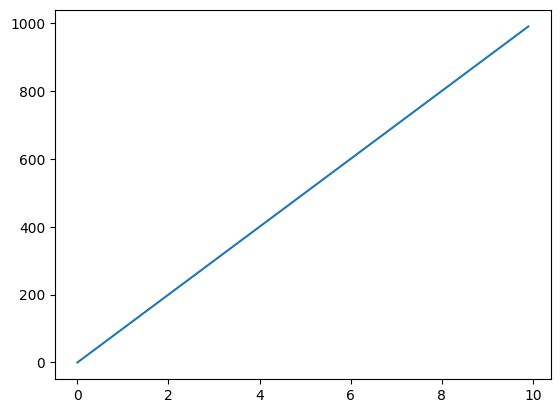

In [ ]:
import matplotlib.pyplot as plt

nPoints = 100
tf = 10
t0 = 0
dt = (tf - t0) / nPoints
t = np.array([n*dt for n in range(nPoints)])
X = np.zeros(nPoints)
dXdt = np.zeros(nPoints-1)
a = 100

def next(X, dXdt, dt):
  return X + dXdt * dt
# xDot = a

for i, x in enumerate(X):
  if i > 0:
    X[i] = next(X[i-1], a, dt)

fig, ax = plt.subplots()
ax.plot(t, X)
plt.show()
